<a href="https://colab.research.google.com/github/AslauAlexandru/QOSF-Tasks/blob/main/QOSF_Task_1_Gate_Tomography_Task_2_Complex_Amplitudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!uv pip install qiskit pennylane pylatexenc
#!pip install qiskit pennylane pylatexenc

Using Python 3.12.12 environment at: /usr
Resolved 29 packages in 3.26s
Prepared 10 packages in 3.59s
Installed 10 packages in 245ms
 + appdirs==1.4.4
 + autoray==0.8.0
 + diastatic-malt==2.15.2
 + pennylane==0.43.0
 + pennylane-lightning==0.43.0
 + pylatexenc==2.10
 + qiskit==2.2.1
 + rustworkx==0.17.1
 + scipy-openblas32==0.3.30.0.2
 + stevedore==5.5.0


# QOSF Task 1 Gate Tomography

## Pennylane

In [2]:
#dev = qml.device("default.qubit", wires=n_wires)
#dev = qml.device("lightning.qubit", wires=n_wires)

In [3]:
import pennylane as qml
from pennylane import numpy as np

# Define the number of qubits
n_wires = 3
#dev = qml.device("default.qubit", wires=n_wires)
dev = qml.device("lightning.qubit", wires=n_wires)

# Define the parameters for the two U3 gates
# U3_1 is Tdg -> U3(0, -pi/4, -pi/4)
params1 = [0, -np.pi / 4, -np.pi / 4]
# U3_2 is T -> U3(0, pi/4, pi/4)
params2 = [0, np.pi / 4, np.pi / 4]

@qml.qnode(dev)
def build_circuit(p1, p2):
    """Builds the quantum circuit from the image."""
    # --- Circuit implementation ---
    qml.T(wires=0)
    qml.U3(p1[0], p1[1], p1[2], wires=2)     # First '?' gate
    qml.CNOT(wires=[0, 1])

    qml.adjoint(qml.T(wires=1))
    qml.CNOT(wires=[0, 1])
    qml.T(wires=1)
    qml.CNOT(wires=[1, 2])

    qml.adjoint(qml.T(wires=2))
    qml.CNOT(wires=[0, 2])
    qml.T(wires=2)
    qml.CNOT(wires=[1, 2])
    qml.U3(p2[0], p2[1], p2[2], wires=2)     # Second '?' gate
    qml.CNOT(wires=[0, 2])
    qml.T(wires=2)
    qml.Hadamard(wires=2)
    return qml.state()

# Get the unitary matrix of our constructed circuit
# Pass wire_order to resolve ambiguity
circuit_matrix = qml.matrix(build_circuit, wire_order=[0, 1, 2])(params1, params2)

# Get the standard Toffoli gate matrix
toffoli_matrix = qml.Toffoli.compute_matrix()

# Check if the matrices are equivalent (up to a global phase)
phase_factor = np.trace(toffoli_matrix.conj().T @ circuit_matrix) / 8
are_equivalent = np.allclose(circuit_matrix / phase_factor, toffoli_matrix)

print("--- PennyLane Verification  ---")
print(f"Parameters for 1st U3 gate (Tdg): {params1}")
print(f"Parameters for 2nd U3 gate (T):   {params2}\n")
print(f"Are the circuit and Toffoli gate equivalent? {are_equivalent}")

--- PennyLane Verification  ---
Parameters for 1st U3 gate (Tdg): [0, -0.7853981633974483, -0.7853981633974483]
Parameters for 2nd U3 gate (T):   [0, 0.7853981633974483, 0.7853981633974483]

Are the circuit and Toffoli gate equivalent? False


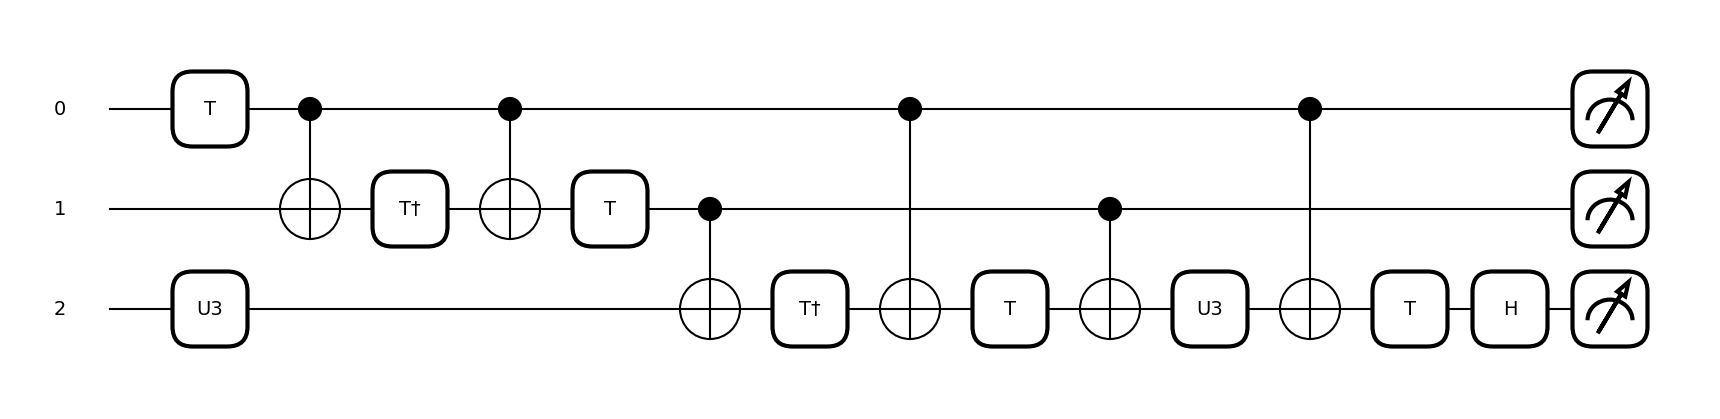

In [4]:
# Draw the quantum circuit in pennylane
fig, ax = qml.draw_mpl(build_circuit)(params1, params2)
fig.show()

In [5]:
 # Draw the quantum circuit in pennylane
print(qml.draw(build_circuit)(params1, params2))

0: ──T────────────────────╭●─────╭●───────────╭●───────────────────────────╭●───────┤  State
1: ───────────────────────╰X──T†─╰X──T─╭●─────│─────╭●─────────────────────│────────┤  State
2: ──U3(0.00,-0.79,-0.79)──────────────╰X──T†─╰X──T─╰X──U3(0.00,0.79,0.79)─╰X──T──H─┤  State


## Qiskit

In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator

# Define the parameters for the two U3 gates
params1 = [0, -np.pi / 4, -np.pi / 4]
params2 = [0, np.pi / 4, np.pi / 4]

# Build the quantum circuit from the image
qc = QuantumCircuit(3)
qc.t(0)
qc.u(params1[0], params1[1], params1[2], 2) # First '?' gate
qc.cx(0, 1)
qc.tdg(1)
qc.cx(0, 1)
qc.t(1)
qc.cx(1, 2)
qc.tdg(2)
qc.cx(0, 2)
qc.t(2)
qc.cx(1, 2)
qc.u(params2[0], params2[1], params2[2], 2) # Second '?' gate
qc.cx(0, 2)
qc.t(2)
qc.h(2)

# Get the unitary operator of our circuit
circuit_op = Operator(qc)

# FIX: Create the Toffoli operator from a QuantumCircuit
toffoli_qc = QuantumCircuit(3)
toffoli_qc.ccx(0, 1, 2)
toffoli_op = Operator(toffoli_qc)

# Check for equivalence (Operator.equiv handles global phase)
are_equivalent = circuit_op.equiv(toffoli_op)

print("--- Qiskit Verification  ---")
print(f"Parameters for 1st U3 gate (Tdg): {params1}")
print(f"Parameters for 2nd U3 gate (T):   {params2}\n")
print(f"Are the circuit and Toffoli gate equivalent? {are_equivalent}")

--- Qiskit Verification  ---
Parameters for 1st U3 gate (Tdg): [0, -0.7853981633974483, -0.7853981633974483]
Parameters for 2nd U3 gate (T):   [0, 0.7853981633974483, 0.7853981633974483]

Are the circuit and Toffoli gate equivalent? False


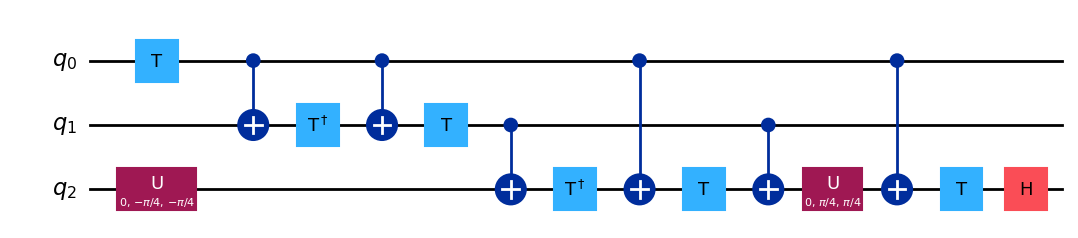

In [7]:
# Draw the quantum circuit in qiskit
qc.draw(output="mpl")

In [8]:
# Draw the quantum circuit in qiskit
qc.draw()

┌───┐                                                        »
q_0: ──────┤ T ├─────────■───────────■─────────────────────■────────────»
           └───┘       ┌─┴─┐┌─────┐┌─┴─┐┌───┐              │            »
q_1: ──────────────────┤ X ├┤ Tdg ├┤ X ├┤ T ├──■───────────┼─────────■──»
     ┌────────────────┐└───┘└─────┘└───┘└───┘┌─┴─┐┌─────┐┌─┴─┐┌───┐┌─┴─┐»
q_2: ┤ U(0,-π/4,-π/4) ├──────────────────────┤ X ├┤ Tdg ├┤ X ├┤ T ├┤ X ├»
     └────────────────┘                      └───┘└─────┘└───┘└───┘└───┘»
«                                    
«q_0: ──────────────────■────────────
«                       │            
«q_1: ──────────────────┼────────────
«     ┌──────────────┐┌─┴─┐┌───┐┌───┐
«q_2: ┤ U(0,π/4,π/4) ├┤ X ├┤ T ├┤ H ├
«     └──────────────┘└───┘└───┘└───┘

In [9]:
# Draw the quantum circuit in qiskit
print(qc)

           ┌───┐                                                        »
q_0: ──────┤ T ├─────────■───────────■─────────────────────■────────────»
           └───┘       ┌─┴─┐┌─────┐┌─┴─┐┌───┐              │            »
q_1: ──────────────────┤ X ├┤ Tdg ├┤ X ├┤ T ├──■───────────┼─────────■──»
     ┌────────────────┐└───┘└─────┘└───┘└───┘┌─┴─┐┌─────┐┌─┴─┐┌───┐┌─┴─┐»
q_2: ┤ U(0,-π/4,-π/4) ├──────────────────────┤ X ├┤ Tdg ├┤ X ├┤ T ├┤ X ├»
     └────────────────┘                      └───┘└─────┘└───┘└───┘└───┘»
«                                    
«q_0: ──────────────────■────────────
«                       │            
«q_1: ──────────────────┼────────────
«     ┌──────────────┐┌─┴─┐┌───┐┌───┐
«q_2: ┤ U(0,π/4,π/4) ├┤ X ├┤ T ├┤ H ├
«     └──────────────┘└───┘└───┘└───┘


## Pennylane

In [10]:
import pennylane as qml
from pennylane import numpy as np

n_wires = 3
#dev = qml.device("default.qubit", wires=n_wires)
dev = qml.device("lightning.qubit", wires=n_wires)
target_matrix = qml.Toffoli.compute_matrix()

def circuit_template(params):
    """The circuit with variable parameters."""
    qml.T(wires=0)
    qml.U3(params[0], params[1], params[2], wires=2)
    qml.CNOT(wires=[0, 1])
    qml.adjoint(qml.T(wires=1))
    qml.CNOT(wires=[0, 1])
    qml.T(wires=1)
    qml.CNOT(wires=[1, 2])
    qml.adjoint(qml.T(wires=2))
    qml.CNOT(wires=[0, 2])
    qml.T(wires=2)
    qml.CNOT(wires=[1, 2])
    qml.U3(params[3], params[4], params[5], wires=2)
    qml.CNOT(wires=[0, 2])
    qml.T(wires=2)
    qml.Hadamard(wires=2)

def cost(params):

    circuit_matrix = qml.matrix(circuit_template, wire_order=[0, 1, 2])(params)
    return np.linalg.norm(circuit_matrix - target_matrix)


optimizer = qml.AdamOptimizer(stepsize=0.1)
params = np.random.uniform(0, 2 * np.pi, 6, requires_grad=True)

print("\n--- PennyLane Optimization ---")
print("Optimizing to find U3 parameters...")


for i in range(101):
    params, loss = optimizer.step_and_cost(cost, params)
    if i % 20 == 0:
        print(f"Step {i:3d}: Cost = {loss:.6f}")

# Clean up final parameters
# Convert to the range [-pi, pi] for easier interpretation
final_params_raw = np.arctan2(np.sin(params), np.cos(params))
# Round to the nearest multiple of pi/4
final_params_clean = np.round(final_params_raw / (np.pi / 4)) * (np.pi / 4)

print("\nOptimization Finished!")
print(f"Final Cost: {loss:.6f}")
print(f"Found Parameters (cleaned): {final_params_clean.tolist()}")
print(f"Expected Parameters 1 (Tdg): [0.0, -{np.pi/4:.4f}, -{np.pi/4:.4f}]")
print(f"Expected Parameters 2 (T):   [0.0,  {np.pi/4:.4f},  {np.pi/4:.4f}]")


--- PennyLane Optimization ---
Optimizing to find U3 parameters...
Step   0: Cost = 3.593877
Step  20: Cost = 3.530391


/usr/local/lib/python3.12/dist-packages/autograd/numpy/numpy_vjps.py:943: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


Step  40: Cost = 3.467539
Step  60: Cost = 3.549606
Step  80: Cost = 3.555548
Step 100: Cost = 3.554527

Optimization Finished!
Final Cost: 3.554527
Found Parameters (cleaned): [-0.0, 3.141592653589793, -1.5707963267948966, -2.356194490192345, 0.7853981633974483, -0.0]
Expected Parameters 1 (Tdg): [0.0, -0.7854, -0.7854]
Expected Parameters 2 (T):   [0.0,  0.7854,  0.7854]


# QOSF Task 2  Complex Amplitudes

In [11]:
import numpy as np

def prepare_two_qubit_state(amplitudes):

    # --- 1. Input Validation ---
    if len(amplitudes) != 4:
        raise ValueError("Input must be a list or array of four complex amplitudes.")

    # Convert to a NumPy array with a complex data type
    state_vector = np.array(amplitudes, dtype=complex)

    # --- 2. Normalization Step ---

    norm_squared = np.sum(np.abs(state_vector)**2)

    # Check if the vector is already normalized (within a small tolerance)
    if not np.isclose(norm_squared, 1.0):
        # If not, calculate the normalization factor and apply it
        norm = np.sqrt(norm_squared)
        if norm == 0:
             raise ValueError("Input amplitudes cannot be all zero.")
        state_vector = state_vector / norm
        print("Note: Input amplitudes were not normalized. Normalization has been applied.")

    # --- 3. Reshape to a column vector ---

    return state_vector.reshape(4, 1)


def prepare_n_qubit_state(amplitudes):

    num_amplitudes = len(amplitudes)
    if num_amplitudes == 0 or (num_amplitudes & (num_amplitudes - 1)) != 0:
        raise ValueError("The number of amplitudes must be a non-zero power of two.")

    # Convert to a complex NumPy array
    state_vector = np.array(amplitudes, dtype=complex)

    # Normalization
    norm_squared = np.sum(np.abs(state_vector)**2)
    if not np.isclose(norm_squared, 1.0):
        norm = np.sqrt(norm_squared)
        if norm == 0:
            raise ValueError("Input amplitudes cannot be all zero.")
        state_vector = state_vector / norm
        print(f"Note: {num_amplitudes}-amplitude input was not normalized. Normalization has been applied.")


    # Reshape to a column vector of size (2^n, 1)
    return state_vector.reshape(num_amplitudes, 1)

In [12]:
import unittest
import numpy as np
#from state_preparation import prepare_two_qubit_state, prepare_n_qubit_state

class TestQuantumStatePreparation(unittest.TestCase):
    """
    Unit tests for the quantum state preparation functions.
    """

    def test_prepare_two_qubit_state_already_normalized(self):
        """
        Tests preparation of an already normalized two-qubit state (Bell state).
        """
        print("\n--- Testing two-qubit state (already normalized) ---")
        bell_state_amps = [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)]
        state_vector = prepare_two_qubit_state(bell_state_amps)

        # 1. Check correct dimension
        self.assertEqual(state_vector.shape, (4, 1))

        # 2. Check if it's correctly normalized
        norm = np.linalg.norm(state_vector)
        self.assertAlmostEqual(norm, 1.0, places=7)

        # 3. Check if the values are correct
        expected_vector = np.array([[1/np.sqrt(2)], [0], [0], [1/np.sqrt(2)]])
        self.assertTrue(np.allclose(state_vector, expected_vector))
        print("✅ Passed")

    def test_prepare_two_qubit_state_needs_normalization(self):
        """
        Tests if the function correctly normalizes a non-normalized input.
        """
        print("\n--- Testing two-qubit state (needs normalization) ---")
        unnormalized_amps = [1, 1, 1, 1]
        state_vector = prepare_two_qubit_state(unnormalized_amps)

        # 1. Check correct dimension
        self.assertEqual(state_vector.shape, (4, 1))

        # 2. Check if normalization was enforced
        norm = np.linalg.norm(state_vector)
        self.assertAlmostEqual(norm, 1.0, places=7)

        # 3. Check if the values are correct (each should be 1/sqrt(4) = 0.5)
        expected_vector = np.array([[0.5], [0.5], [0.5], [0.5]])
        self.assertTrue(np.allclose(state_vector, expected_vector))
        print("✅ Passed")

    def test_two_qubit_invalid_input_length(self):
        """
        Tests if the function raises a ValueError for incorrect input length.
        """
        print("\n--- Testing two-qubit state (invalid input length) ---")
        with self.assertRaises(ValueError):
            prepare_two_qubit_state([1, 2, 3])
        print("✅ Passed (ValueError was correctly raised)")

    # --- Tests for the Stretch Goal (n-qubit) ---

    def test_prepare_three_qubit_state(self):
        """
        Tests the generalized function for a 3-qubit state (GHZ state).
        """
        print("\n--- Testing three-qubit state (GHZ state) ---")
        ghz_state_amps = [1/np.sqrt(2), 0, 0, 0, 0, 0, 0, 1/np.sqrt(2)]
        state_vector = prepare_n_qubit_state(ghz_state_amps)

        # 1. Check correct dimension (2^3 = 8)
        self.assertEqual(state_vector.shape, (8, 1))

        # 2. Check normalization
        norm = np.linalg.norm(state_vector)
        self.assertAlmostEqual(norm, 1.0, places=7)
        print("✅ Passed")

    def test_prepare_n_qubit_state_needs_normalization(self):
        """
        Tests normalization for the generalized n-qubit function.
        """
        print("\n--- Testing three-qubit state (needs normalization) ---")
        # A 1-qubit state for simplicity
        unnormalized_amps = [3, 4] # norm should be sqrt(9+16) = 5
        state_vector = prepare_n_qubit_state(unnormalized_amps)

        # 1. Check correct dimension (2^1 = 2)
        self.assertEqual(state_vector.shape, (2, 1))

        # 2. Check normalization
        norm = np.linalg.norm(state_vector)
        self.assertAlmostEqual(norm, 1.0, places=7)

        # 3. Check values
        expected_vector = np.array([[0.6], [0.8]])
        self.assertTrue(np.allclose(state_vector, expected_vector))
        print("✅ Passed")

    def test_n_qubit_invalid_input_length(self):
        """
        Tests if the n-qubit function rejects lengths that are not a power of two.
        """
        print("\n--- Testing n-qubit state (invalid input length) ---")
        with self.assertRaises(ValueError):
            prepare_n_qubit_state([1, 2, 3, 4, 5, 6]) # Length 6 is not a power of 2
        print("✅ Passed (ValueError was correctly raised)")


if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)


......
----------------------------------------------------------------------
Ran 6 tests in 0.007s

OK



--- Testing n-qubit state (invalid input length) ---
✅ Passed (ValueError was correctly raised)

--- Testing three-qubit state (needs normalization) ---
Note: 2-amplitude input was not normalized. Normalization has been applied.
✅ Passed

--- Testing three-qubit state (GHZ state) ---
✅ Passed

--- Testing two-qubit state (already normalized) ---
✅ Passed

--- Testing two-qubit state (needs normalization) ---
Note: Input amplitudes were not normalized. Normalization has been applied.
✅ Passed

--- Testing two-qubit state (invalid input length) ---
✅ Passed (ValueError was correctly raised)
